# Logistic Regression 与 Lasso 对比实验

这个 notebook 直接读取已经处理好的训练数据，分别训练 Logistic Regression（L2）和 Lasso（L1 Logistic Regression）两个模型。

实验要求：
- 每个模型单独成块执行
- 使用 SMOTE 处理类别不平衡
- 使用交叉验证做超参数调优
- 评价两个维度：Accuracy 和 Interpretation
- 过程中的说明和注释全部用中文

In [10]:
# 导入需要的库
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, average_precision_score, roc_curve, auc, precision_recall_curve

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 设定一个更适合中文显示的字体栈，避免图表中的中文变成方框
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False

print('库导入完成，可以开始实验。')

库导入完成，可以开始实验。


In [11]:
# 读取训练数据
# 这里优先从当前 notebook 所在目录上一级的 data 文件夹读取，便于在不同工作目录下直接运行
def load_processed_data():
    candidate_dirs = [
        os.path.abspath(os.path.join(os.getcwd(), '..', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), 'data')),
        'data'
    ]

    for data_dir in candidate_dirs:
        x_path = os.path.join(data_dir, 'X_train_processed.csv')
        y_path = os.path.join(data_dir, 'y_train_processed.csv')
        if os.path.exists(x_path) and os.path.exists(y_path):
            X = pd.read_csv(x_path)
            y = pd.read_csv(y_path).iloc[:, 0]
            print(f'成功读取数据：{os.path.abspath(data_dir)}')
            return X, y

    raise FileNotFoundError('没有找到 processed 训练数据，请确认 data 目录中存在 X_train_processed.csv 和 y_train_processed.csv。')

X, y = load_processed_data()

print('X 的形状：', X.shape)
print('y 的形状：', y.shape)
print('特征列：', list(X.columns))
print('标签分布：')
display(y.value_counts().rename('count').to_frame())
print('标签比例：')
display((y.value_counts(normalize=True).rename('ratio') * 100).round(2).to_frame())

成功读取数据：/Users/dazhaxie/Desktop/NTU/6122/6122-group-project/data
X 的形状： (120000, 10)
y 的形状： (120000,)
特征列： ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
标签分布：


,count
SeriousDlqin2yrs,
0,111979
1,8021


标签比例：


,ratio
SeriousDlqin2yrs,
0,93.32
1,6.68


In [12]:
# 定义一个通用训练函数：完成预处理、SMOTE、交叉验证调参、评估与可解释性输出（以 ROC_AUC 为 refit，同时报告 PR-AUC）
def train_with_cv(name, estimator, param_grid, X, y, random_state=42, cv_splits=5):
    print(f'\n========== 开始训练：{name} ==========' )

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=random_state)),
        ('clf', estimator)
    ])

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'average_precision': 'average_precision'}

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit='roc_auc',
        cv=cv,
        return_train_score=True,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X, y)
    best_model = search.best_estimator_

    # 使用交叉验证的概率预测来绘制无偏的 ROC/PR 曲线（cross_val_predict 在每个折内独立训练）
    try:
        probas_cv = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba', n_jobs=-1)
        y_scores = probas_cv[:, 1]
        fpr, tpr, _ = roc_curve(y, y_scores)
        roc_auc_cv = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(y, y_scores)
        pr_auc_cv = average_precision_score(y, y_scores)

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_cv:.4f})', color='#457b9d')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC 曲线')
        plt.legend(loc='lower right')

        plt.subplot(1, 2, 2)
        plt.plot(recall, precision, label=f'PR (AP = {pr_auc_cv:.4f})', color='#e76f51')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} - Precision-Recall 曲线')
        plt.legend(loc='lower left')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('绘制 ROC/PR 曲线失败：', e)
        y_scores = None
        roc_auc_cv = np.nan
        pr_auc_cv = np.nan

    # 在整个训练集上评估（注意：这不是无偏估计，推荐参考上面的 CV 曲线）
    y_pred = best_model.predict(X)
    train_acc = accuracy_score(y, y_pred)
    try:
        y_proba_full = best_model.predict_proba(X)[:, 1]
        train_ap = average_precision_score(y, y_proba_full)
    except Exception:
        y_proba_full = None
        train_ap = np.nan

    # 打印并保存一些 CV 指标（以 best_index_ 为准）
    best_idx = search.best_index_
    mean_roc = search.cv_results_.get('mean_test_roc_auc', [np.nan])[best_idx]
    mean_acc = search.cv_results_.get('mean_test_accuracy', [np.nan])[best_idx]
    mean_ap = search.cv_results_.get('mean_test_average_precision', [np.nan])[best_idx]

    print('最优超参数：', search.best_params_)
    print(f'交叉验证 (mean) ROC_AUC：{mean_roc:.4f} | CV Accuracy：{mean_acc:.4f} | CV AP：{mean_ap:.4f}')
    print(f'训练集 Accuracy：{train_acc:.4f} | 训练集 AP：{train_ap if not np.isnan(train_ap) else 'N/A'}')

    clf = best_model.named_steps['clf']
    coef_df = None
    nonzero_coef = np.nan
    if hasattr(clf, 'coef_'):
        coefs = clf.coef_.ravel()
        coef_df = pd.DataFrame({
            'feature': X.columns,
            'coef': coefs,
            'abs_coef': np.abs(coefs)
        }).sort_values('abs_coef', ascending=False)
        nonzero_coef = int((np.abs(coefs) > 1e-8).sum())
        print(f'非零系数数量：{nonzero_coef} / {len(coefs)}')
        display(coef_df.head(10))

        top_features = coef_df.head(10).sort_values('coef')
        plt.figure(figsize=(10, 6))
        colors = ['#2a9d8f' if value > 0 else '#e76f51' for value in top_features['coef']]
        plt.barh(top_features['feature'], top_features['coef'], color=colors)
        plt.axvline(0, color='black', linewidth=1)
        plt.title(f'{name}：绝对值最大的 10 个系数')
        plt.xlabel('系数值')
        plt.ylabel('特征')
        plt.tight_layout()
        plt.show()

    result = {
        'model': name,
        'best_params': search.best_params_,
        'cv_roc_auc': mean_roc,
        'cv_accuracy': mean_acc,
        'cv_average_precision': mean_ap,
        'train_accuracy': train_acc,
        'train_average_precision': train_ap,
        'cv_roc_auc_curve': (fpr, tpr) if y_scores is not None else None,
        'cv_pr_curve': (precision, recall) if y_scores is not None else None,
        'nonzero_coefficients': nonzero_coef,
        'coef_table': coef_df,
        'best_estimator': best_model
    }

    print(f'========== {name} 训练完成 ==========' )
    return result

## 模型一：Logistic Regression（L2 正则）

这一部分单独训练 Logistic Regression，并通过 GridSearchCV 调整正则强度 `C`。

这里的解释性主要看两点：
1. 系数绝对值越大，说明这个特征对预测的影响越明显。
2. 系数方向可以解释特征对违约风险是正向还是负向影响。


========== 开始训练：Logistic Regression (L2) ==========
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

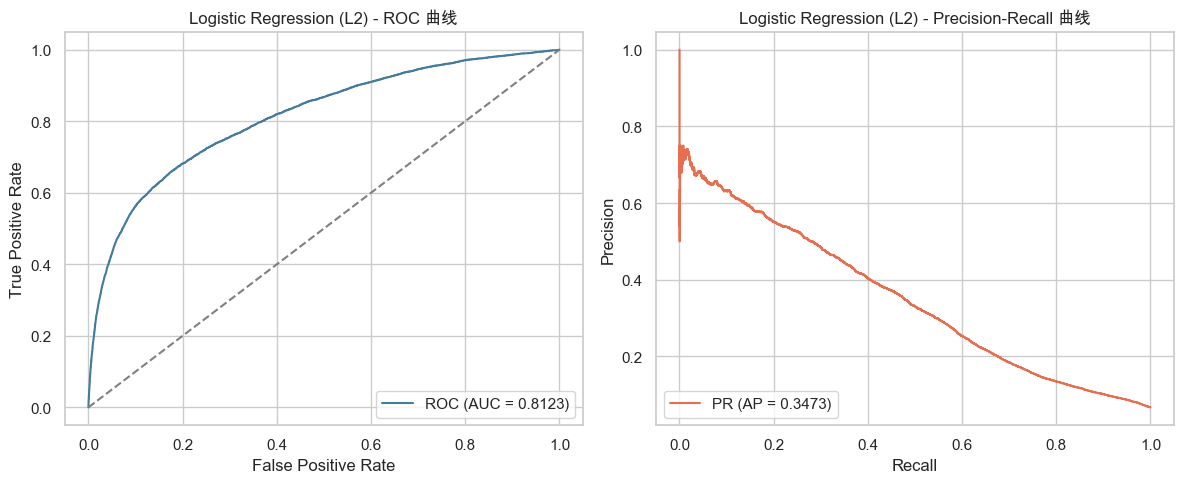

最优超参数： {'clf__C': 0.01}
交叉验证 (mean) ROC_AUC：0.8124 | CV Accuracy：0.8404 | CV AP：0.3484
训练集 Accuracy：0.8421 | 训练集 AP：0.34772209156905787
非零系数数量：10 / 10


,feature,coef,abs_coef
6,NumberOfTimes90DaysLate,0.609237,0.609237
2,NumberOfTime30-59DaysPastDueNotWorse,0.504532,0.504532
1,age,-0.453481,0.453481
4,MonthlyIncome,-0.394680,0.394680
8,NumberOfTime60-89DaysPastDueNotWorse,0.360844,0.360844
3,DebtRatio,-0.224066,0.224066
7,NumberRealEstateLoansOrLines,0.137151,0.137151
9,NumberOfDependents,0.024191,0.024191
0,RevolvingUtilizationOfUnsecuredLines,-0.009713,0.009713
5,NumberOfOpenCreditLinesAndLoans,-0.003607,0.003607


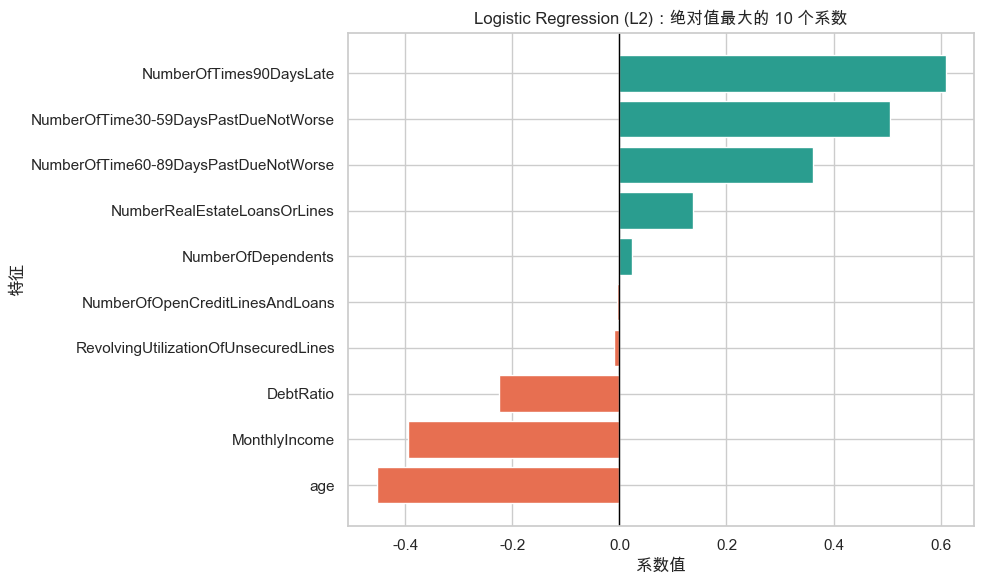

========== Logistic Regression (L2) 训练完成 ==========


In [13]:
# Logistic Regression：使用 L2 正则
logreg = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=3000)
logreg_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 50.0]
}

logreg_result = train_with_cv('Logistic Regression (L2)', logreg, logreg_grid, X, y)

## 模型二：Lasso（L1 Logistic Regression）

这一部分使用 L1 正则，也就是常说的 Lasso 风格逻辑回归。它的优点是可以把一部分不重要的系数压到 0，形成更稀疏的模型。

因此这里的可解释性除了看系数大小，也可以看非零系数数量：非零系数越少，模型通常越容易解释。


========== 开始训练：Lasso (L1 Logistic Regression) ==========
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

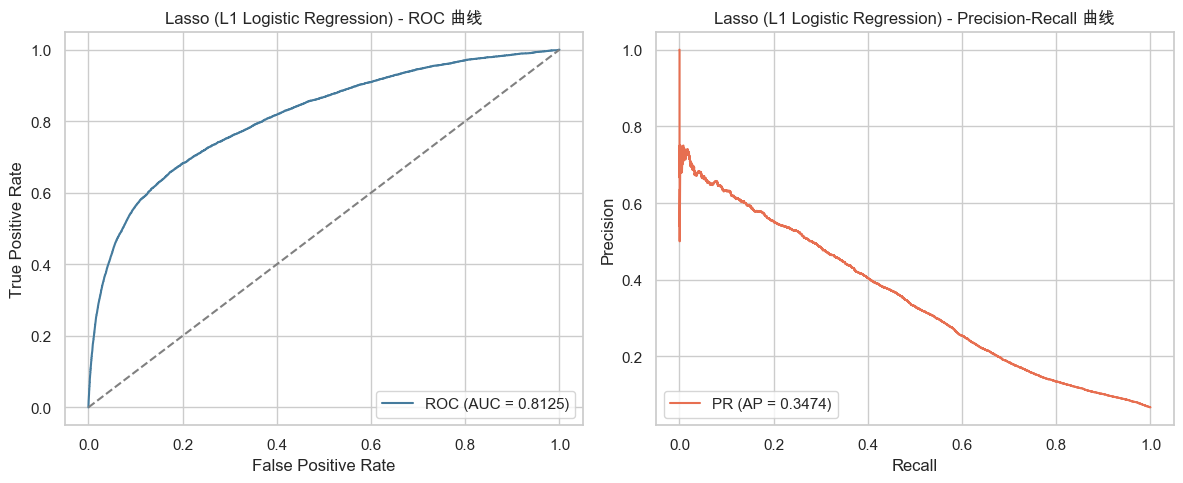

最优超参数： {'clf__C': 0.01}
交叉验证 (mean) ROC_AUC：0.8125 | CV Accuracy：0.8413 | CV AP：0.3485
训练集 Accuracy：0.8427 | 训练集 AP：0.3477398557306658
非零系数数量：9 / 10


,feature,coef,abs_coef
6,NumberOfTimes90DaysLate,0.608377,0.608377
2,NumberOfTime30-59DaysPastDueNotWorse,0.503155,0.503155
1,age,-0.453310,0.453310
4,MonthlyIncome,-0.375619,0.375619
8,NumberOfTime60-89DaysPastDueNotWorse,0.359053,0.359053
3,DebtRatio,-0.213857,0.213857
7,NumberRealEstateLoansOrLines,0.131010,0.131010
9,NumberOfDependents,0.021789,0.021789
0,RevolvingUtilizationOfUnsecuredLines,-0.005247,0.005247
5,NumberOfOpenCreditLinesAndLoans,0.000000,0.000000


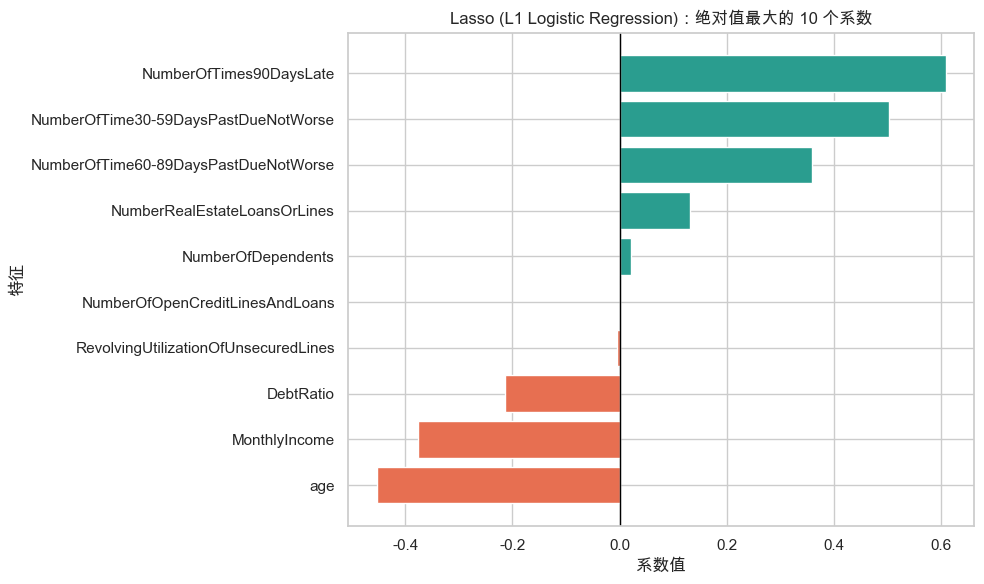

========== Lasso (L1 Logistic Regression) 训练完成 ==========


In [14]:
# Lasso 风格的 Logistic Regression：使用 L1 正则
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=5000)
lasso_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 50.0]
}

lasso_result = train_with_cv('Lasso (L1 Logistic Regression)', lasso, lasso_grid, X, y)

## 结果对比与分析

这一部分直接在 notebook 里对比两个模型的交叉验证准确率、训练集准确率和可解释性指标，不输出任何外部表格文件。

如果 Lasso 的准确率和 Logistic Regression 接近，但非零系数更少，那么它通常会是更有解释性的选择。

,模型,CV ROC_AUC,CV AP,CV Accuracy,训练集 Accuracy,训练集 AP,非零系数数量
0,Logistic Regression (L2),0.8124,0.3484,0.8404,0.8421,0.3477,10
1,Lasso (L1 Logistic Regression),0.8125,0.3485,0.8413,0.8427,0.3477,9


/var/folders/81/184ffccs2kl1v86z8r9wjgl00000gn/T/ipykernel_76190/2646303549.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='模型', y='CV ROC_AUC', ax=axes[0], palette=['#457b9d', '#e76f51'])
/var/folders/81/184ffccs2kl1v86z8r9wjgl00000gn/T/ipykernel_76190/2646303549.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='模型', y='CV AP', ax=axes[1], palette=['#457b9d', '#e76f51'])
/var/folders/81/184ffccs2kl1v86z8r9wjgl00000gn/T/ipykernel_76190/2646303549.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.bar

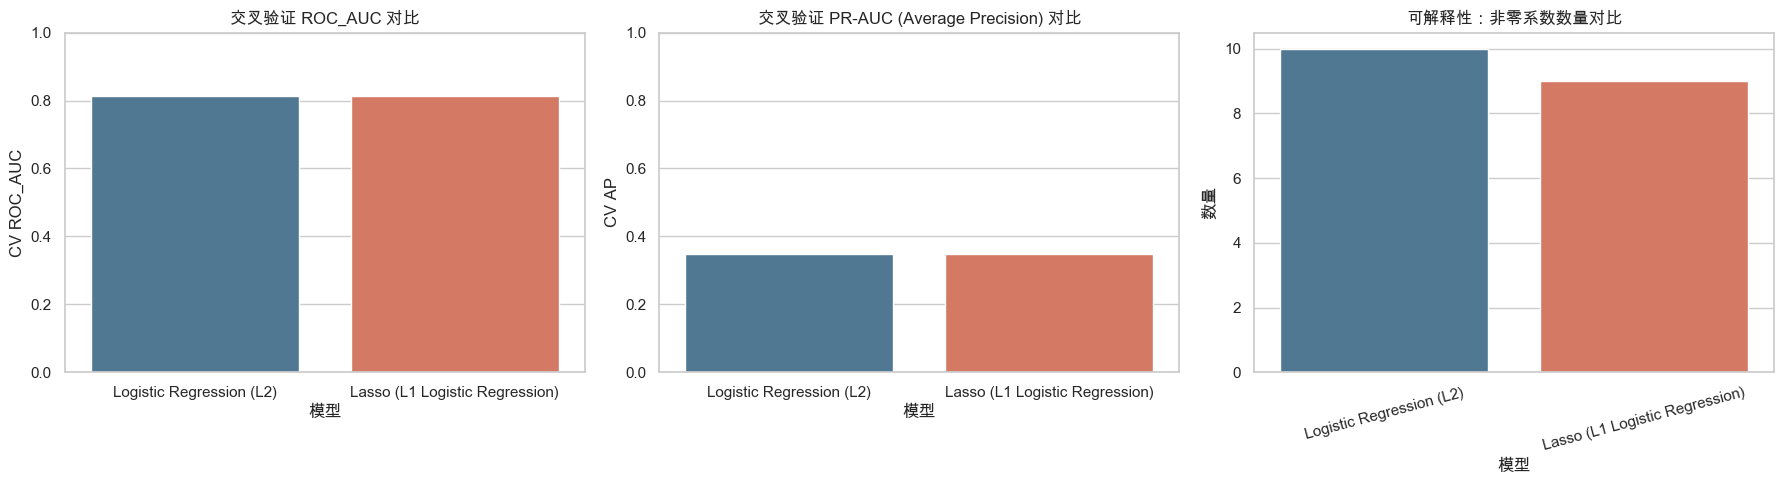

分析提示：
1. 主指标为 CV ROC_AUC（越接近 1 越好），次要报告为 CV PR-AUC（Average Precision），尤其在正类稀少时参考价值更高。
2. 若 ROC_AUC 相近，但 Lasso 的非零系数明显更少，则 Lasso 更有解释性。
3. 若你需要基于特定阈值做决策，请在独立验证集上查看 precision/recall 曲线并选取合适阈值。


In [16]:
# 汇总对比结果并可视化
# 汇总对比结果并可视化（重点：ROC_AUC 为主，报告 PR-AUC）
comparison = pd.DataFrame([
    {
        '模型': logreg_result['model'],
        'CV ROC_AUC': logreg_result.get('cv_roc_auc', np.nan),
        'CV AP': logreg_result.get('cv_average_precision', np.nan),
        'CV Accuracy': logreg_result.get('cv_accuracy', np.nan),
        '训练集 Accuracy': logreg_result.get('train_accuracy', np.nan),
        '训练集 AP': logreg_result.get('train_average_precision', np.nan),
        '非零系数数量': logreg_result.get('nonzero_coefficients', np.nan),
    },
    {
        '模型': lasso_result['model'],
        'CV ROC_AUC': lasso_result.get('cv_roc_auc', np.nan),
        'CV AP': lasso_result.get('cv_average_precision', np.nan),
        'CV Accuracy': lasso_result.get('cv_accuracy', np.nan),
        '训练集 Accuracy': lasso_result.get('train_accuracy', np.nan),
        '训练集 AP': lasso_result.get('train_average_precision', np.nan),
        '非零系数数量': lasso_result.get('nonzero_coefficients', np.nan),
    }
])

display(comparison.round(4))

# 绘制并列柱状图：CV ROC_AUC、CV AP、非零系数数量
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=comparison, x='模型', y='CV ROC_AUC', ax=axes[0], palette=['#457b9d', '#e76f51'])
axes[0].set_title('交叉验证 ROC_AUC 对比')
axes[0].set_ylim(0, 1)

sns.barplot(data=comparison, x='模型', y='CV AP', ax=axes[1], palette=['#457b9d', '#e76f51'])
axes[1].set_title('交叉验证 PR-AUC (Average Precision) 对比')
axes[1].set_ylim(0, 1)

sns.barplot(data=comparison, x='模型', y='非零系数数量', ax=axes[2], palette=['#457b9d', '#e76f51'])
axes[2].set_title('可解释性：非零系数数量对比')
axes[2].set_ylabel('数量')

for ax in axes:
    ax.set_xlabel('模型')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('分析提示：')
print('1. 主指标为 CV ROC_AUC（越接近 1 越好），次要报告为 CV PR-AUC（Average Precision），尤其在正类稀少时参考价值更高。')
print('2. 若 ROC_AUC 相近，但 Lasso 的非零系数明显更少，则 Lasso 更有解释性。')
print('3. 若你需要基于特定阈值做决策，请在独立验证集上查看 precision/recall 曲线并选取合适阈值。')